In [1]:
from langgraph.graph import StateGraph, START, END 
from typing import TypedDict, Literal, List, Sequence, Annotated

In [2]:
class EmployeeState (TypedDict):
    name:str
    salary: float
    age:int
    decision: Literal["std_hr","forced_hr"]
    result:str

In [3]:
def analyze_employee(state:EmployeeState)->EmployeeState:
    age=state['age']
    salary=state['salary']
    if age<=30 and salary<=40000:
        state['decision']="std_hr"
    else:
        state['decision']="forced_hr"
        print(f"le dossier de {state['name']} à été analyse")
    return state

In [4]:
def standard_hr_process(state:EmployeeState):
    state['result']=f"le dossier de {state['name']} a ete traite de maniere standard"
    print("*"*80)
    print(f"le dossier de {state['name']} a ete traite de maniere standard")
    print(f"name: {state['name']} salary: {state['salary']} age: {state['age']}")
    print("*"*80)
    return state

In [5]:
def forced_hr_process(state:EmployeeState):
    state['result']=f"le dossier de {state['name']} a ete traite de maniere forcee"
    print("="*80)
    print(f"le dossier de {state['name']} a ete traite de maniere forcee")
    print(f"name: {state['name']} salary: {state['salary']} age: {state['age']}")
    print("="*80)
    return state

In [6]:
def router (state:EmployeeState):
    return state ['decision']

In [7]:
workflow = StateGraph(EmployeeState)
workflow.add_node("analyze_node", analyze_employee)
workflow.add_node("standard_node", standard_hr_process)
workflow.add_node("forced_node", forced_hr_process)


In [8]:

workflow.add_edge(START, "analyze_node")


In [9]:

workflow.add_conditional_edges(
    "analyze_node",
router, {
"std_hr":"standard_node",
"forced_hr":"forced_node"
})


In [10]:
workflow.add_edge("standard_node",END)
workflow.add_edge("forced_node",END)
graph =workflow.compile()

In [11]:
from IPython.display import Image

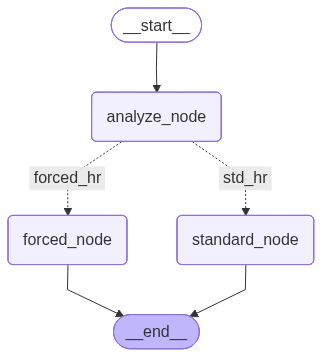

In [12]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [13]:
result= graph.invoke ({
    "name":"wissal", "age":21, "salary":35000
})

********************************************************************************
le dossier de wissal a ete traite de maniere standard
name: wissal salary: 35000 age: 21
********************************************************************************


In [14]:
print(result)

{'name': 'wissal', 'salary': 35000, 'age': 21, 'decision': 'std_hr', 'result': 'le dossier de wissal a ete traite de maniere standard'}


In [15]:
result= graph.invoke ({
    "name":"wissal", "age":35, "salary":35000
})

le dossier de wissal à été analyse
le dossier de wissal a ete traite de maniere forcee
name: wissal salary: 35000 age: 35


In [16]:
print(result)

{'name': 'wissal', 'salary': 35000, 'age': 35, 'decision': 'forced_hr', 'result': 'le dossier de wissal a ete traite de maniere forcee'}


In [17]:
from langchain.tools import tool
from langchain.messages import SystemMessage, AIMessage, ToolMessage,HumanMessage
from langchain_core.messages import BaseMessage, AnyMessage
from langgraph.graph import add_messages
from langchain_openai import ChatOpenAI
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import InMemorySaver


In [18]:
@tool
def add(a: float, b: float):
    """
    Add two float numbers
    """
    print(f"Adding 2 numbers a={a}, b={b}\n")
    return a + b


@tool
def multiply(a: float, b: float):
    """
    Multiply two float numbers
    """
    print(f"Multiplying 2 numbers a={a}, b={b}\n")
    return a * b


@tool
def divide(a: float, b: float):
    """
    Divide two float numbers
    """
    print(f"Dividing 2 numbers a={a}, b={b}\n")
    
    if b == 0:
        return "Error: Division by zero is not allowed"
    
    return a / b



tools = [add, multiply, divide]

In [19]:
class AgentState (TypedDict):
    messages:Annotated[Sequence[BaseMessage],add_messages]

In [20]:
import os
from dotenv import load_dotenv

In [21]:
load_dotenv()

True

In [22]:
llm=ChatOpenAI(model="gpt-4o", temperature=0)
llm_with_tools = llm.bind_tools(tools=tools)

In [23]:
def assistant(state: AgentState)->AgentState:
  response = llm_with_tools.invoke(state['messages'])
  print("*"*50)
  print("llm invoked")
  return {"messages":[response]}

In [24]:
def shoud_continue(state : AgentState):
   last_message = state['messages'][-1]
   if not last_message.tool_calls:
     return "end"
   else:
    return "continue"  

In [25]:
workflow= StateGraph(AgentState)
workflow.add_node("assistant", assistant)
workflow.add_node("tools", ToolNode(tools=tools))
workflow.set_entry_point("assistant") 
workflow.add_conditional_edges(
    "assistant",
    shoud_continue, {
        "end":END, 
        "continue":"tools"
    }
)
workflow.add_edge("tools","assistant")
memory=InMemorySaver()
graph=workflow.compile(checkpointer=memory)

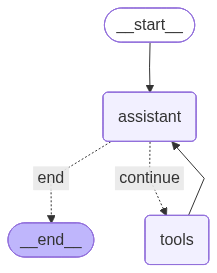

In [26]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [28]:
config={"configurable":{"thread_id":1}}
resp = graph.invoke({
    "messages":[
        HumanMessage("add 5 to 20 then multiply the result by 2 then give me a proverbe in arabic ")
    ]

},config=config)

**************************************************
llm invoked
Adding 2 numbers a=5.0, b=20.0

Multiplying 2 numbers a=25.0, b=2.0

**************************************************
llm invoked


In [29]:
print(resp['messages'][-1].content)

The result of adding 5 to 20 is 25, and multiplying that result by 2 gives 50.

Here's a proverb in Arabic:
"الصبر مفتاح الفرج" 
(Translation: Patience is the key to relief.)


In [30]:
resp = graph.invoke({
    "messages":[
        HumanMessage("Bonjour je m'appelle wissal ")
    ]

},config=config)
print(resp['messages'][-1].content)

**************************************************
llm invoked
Bonjour Wissal ! Comment puis-je vous aider aujourd'hui ?


In [31]:
resp = graph.invoke({
    "messages":[
        HumanMessage("Bonjour comment je m appelle ")
    ]

},config=config)
print(resp['messages'][-1].content)

**************************************************
llm invoked
Bonjour ! Vous venez de mentionner que vous vous appelez Wissal. Comment puis-je vous aider aujourd'hui ?
